In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')
display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


Load the dataset and import the libraries needed. Pandas for handling data, numpy for numeric operatoins, matplotlib for plotting and statsmodels for fitting the regression model.

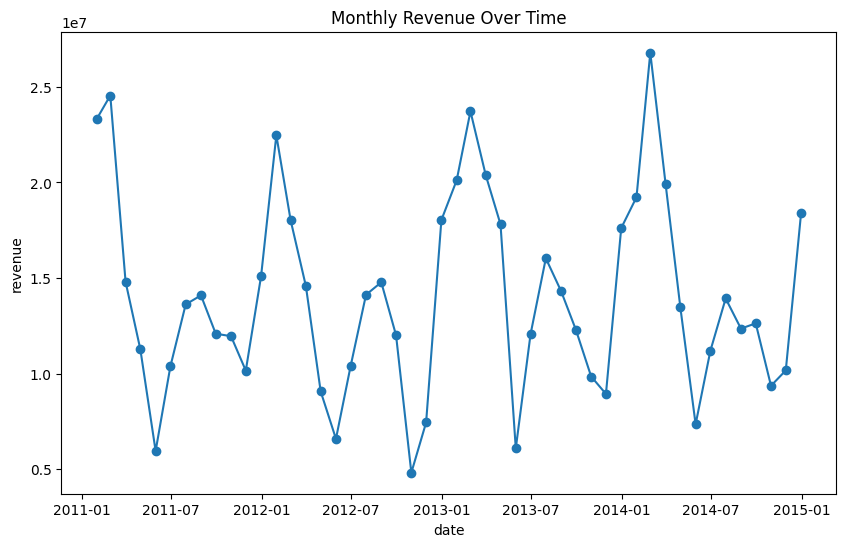

In [ ]:
HS_data['date'] = pd.to_datetime(HS_data['date'])

plt.figure(figsize=(10, 6))
plt.title('Monthly Revenue Over Time')
plt.xlabel('date')
plt.ylabel('revenue')
plt.plot(HS_data['date'], HS_data['revenue'], marker='o')
plt.show()

Convert 'date' to an actual datetime type so it plots correctly on a time axis.

In [ ]:
HS_data.loc[:, ['revenue', 'production', 'coolDD', 'heatDD']].corr()

,revenue,production,coolDD,heatDD
revenue,1.00,0.63,-0.17,0.69
production,0.63,1.00,0.51,0.03
coolDD,-0.17,0.51,1.00,-0.72
heatDD,0.69,0.03,-0.72,1.00


Check how strongly coolDD and heatDD eahc correlate with revenue. This gives an early signal of which feature might be the stronger predictor, before formally testing it.

In [ ]:
dt4training = HS_data.loc[HS_data['type'] == 'dt4training']
dt4testing = HS_data.loc[HS_data['type'] == 'dt4testing']

Seperate the data into training and testing sets.

In [ ]:
y = dt4training.loc[:, 'revenue']

x1 = dt4training.loc[:, 'coolDD']
x1 = sm.add_constant(x1)

model1 = sm.OLS(y, x1).fit()
model1.params

,0
const,14341632.04
coolDD,-4113.94


Training model 1: Fit an OLS regression of revenue on coolDD alone, using only the traning data. sm.add_constant adds the intercept term, and sm.OLS(y,x).fit() solves for the coefficient and intercept that minimize error on the training set.

In [ ]:
x2 = dt4training.loc[:, 'heatDD']
x2 = sm.add_constant(x2)

model2 = sm.OLS(y, x2).fit()
model2.params

,0
const,10333861.28
heatDD,9991.26


Model 2: Identical process but using heatDD as the feature.

In [ ]:
x1_test = dt4testing.loc[:, 'coolDD']
x1_test = sm.add_constant(x1_test)
model1_pred = model1.predict(x1_test)

x2_test = dt4testing.loc[:, 'heatDD']
x2_test = sm.add_constant(x2_test)
model2_pred = model2.predict(x2_test)

Use both models to forecast revenue on the testing data.

In [ ]:
comparison = dt4testing.copy()

comparison['model1_predicted_revenue'] = model1_pred
comparison['model2_predicted_revenue'] = model2_pred

comparison['model1_pct_error'] = abs((comparison['revenue'] - comparison['model1_predicted_revenue']) / comparison['revenue'])
comparison['model2_pct_error'] = abs((comparison['revenue'] - comparison['model2_predicted_revenue']) / comparison['revenue'])

display(comparison)

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model2_predicted_revenue,model1_pct_error,model2_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,14341632.04,21554043.42,0.25,0.12
37,dt4testing,2014-02-28,26792280,714128,0,938,14341632.04,19705660.79,0.46,0.26
38,dt4testing,2014-03-31,19935840,805600,0,866,14341632.04,18986290.25,0.28,0.05
39,dt4testing,2014-04-30,13468000,375856,0,412,14341632.04,14450259.35,0.06,0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,14140049.20,11213091.93,0.93,0.53
41,dt4testing,2014-06-30,11196216,517600,230,0,13395426.88,10333861.28,0.20,0.08
42,dt4testing,2014-07-31,13929472,749472,380,0,12778336.56,10333861.28,0.08,0.26
43,dt4testing,2014-08-31,12352176,663432,322,0,13016944.82,10333861.28,0.05,0.16
44,dt4testing,2014-09-30,12628944,701656,178,14,13609351.53,10473738.88,0.08,0.17
45,dt4testing,2014-10-31,9361000,411728,24,166,14242897.59,11992410.02,0.52,0.28


Calculating the percentage error for each prediction, row by row, so we can then average it into a MAPE score for each model.

In [ ]:
model1_mape = comparison['model1_pct_error'].mean()
model2_mape = comparison['model2_pct_error'].mean()

print('Model 1 (coolDD) MAPE:', model1_mape)
print('Model 2 (heatDD) MAPE:', model2_mape)

Model 1 (coolDD) MAPE: 0.2960295810593141
Model 2 (heatDD) MAPE: 0.21648503280089135


the MAPE is average of those percentage errors which is the standard way to score forecast accuracy. Lower is better.

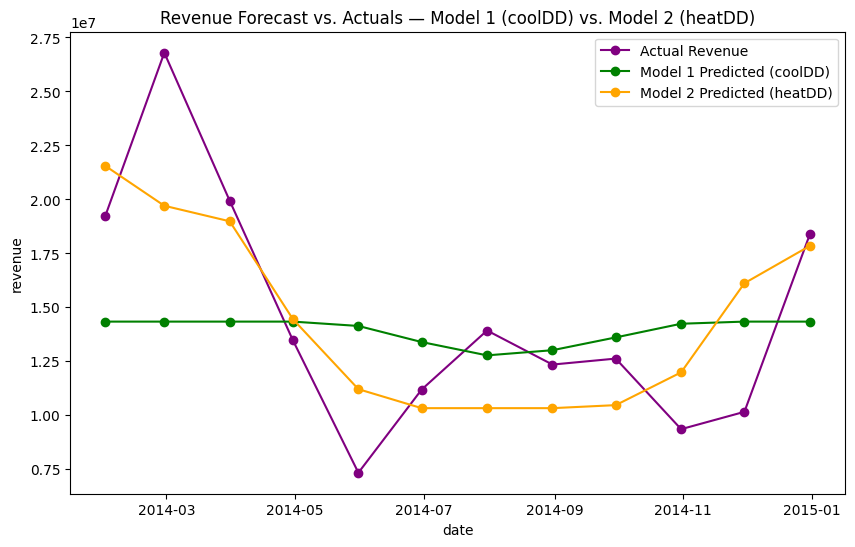

In [ ]:
plt.figure(figsize=(10, 6))

plt.title('Revenue Forecast vs. Actuals — Model 1 (coolDD) vs. Model 2 (heatDD)')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(comparison['date'], comparison['revenue'], marker='o', color='purple', label='Actual Revenue')
plt.plot(comparison['date'], comparison['model1_predicted_revenue'], marker='o', color='green', label='Model 1 Predicted (coolDD)')
plt.plot(comparison['date'], comparison['model2_predicted_revenue'], marker='o', color='orange', label='Model 2 Predicted (heatDD)')

plt.legend()
plt.show()

Plot actual revenue against both models predicted revenue over the testing period. Whichever predicted line tracks the actual line most closely is the better performing model.

Memo: Model 2 (heatDD) outperforms Model 1 (coolDD), with a MAPE of approximately 21.6% versus approx 29.6%. This lines up with the correlation check, where heatDD showed a much stronger relationship with revenue. If choosing one single model, heatDD is the better predictor.